## Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import math 
from random import random 
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from pathlib import Path 
import librosa 
import json 
from collections import defaultdict
from torchvision.transforms import ToTensor
from torchvision import datasets
from torch.utils.data import Subset

## Set up GPU 

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Device: {device}")

Device: mps


## Setup

In [3]:
SEED = 42 
torch.manual_seed(SEED)
np.random.seed(SEED)

## Data

### MNIST Dataset

In [4]:
def download_mnist_datasets():
    train_data = datasets.MNIST(
        root="data", 
        train=True, 
        download=True,
        transform=ToTensor()
    )
    
    test_data = datasets.MNIST(
        root="data",
        train=False,
        download=True,
        transform=ToTensor()
    )

    return train_data, test_data

## Dataset Processing

In [5]:
def prepare_datasets(valid_size):
    # load data 
    train_data, test_data = download_mnist_datasets() 

    # data split 
    indices = list(range(len(train_data)))
    targets = [train_data.targets[i].item() for i in indices]
    train_indices, valid_indices = train_test_split(
        indices, 
        test_size=valid_size, 
        random_state=SEED,
        stratify=targets,
    )

    # create splits 
    train_subset = Subset(train_data, train_indices)
    valid_subset = Subset(train_data, valid_indices)

    # create data loaders 
    train_dataloader = DataLoader(train_subset, batch_size=32, shuffle=True) 
    valid_dataloader = DataLoader(valid_subset, batch_size=32)
    test_dataloader = DataLoader(test_data, batch_size=32)

    return train_dataloader, valid_dataloader, test_dataloader

In [6]:
train_dataloader, valid_dataloader, test_dataloader = prepare_datasets(0.2)

## Neural Network Architecture - Feed-Forward Neural Network (FFNN)

In [7]:
# neural network architecture 
class MNISTFeedForward(nn.Module):
    def __init__(self, num_classes=10, dropout_prob=0.3):
        super().__init__()
        # build a model
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(256, 128), # dense layer/fully connected layer in keras
            nn.ReLU(),
            nn.Dropout(dropout_prob),
            nn.Linear(128, num_classes),
        )
        
    def forward(self, x):
        return self.net(x)

def train(model, train_dataloader, valid_dataloader, optimizer, loss_fn, device, epochs=50):
    history = defaultdict(list)
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for x_batch, y_batch in train_dataloader:
            # get a sample of data 
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)

            # set the gradients to 0 
            optimizer.zero_grad()
            
            # run forward pass
            preds = model(x_batch)
            
            # run cross entropy loss
            loss = loss_fn(preds, y_batch)
            
            # run backward pass
            loss.backward()
            
            # update parameters
            optimizer.step()
 
            # accumulate training loss
            train_loss += loss.item() * x_batch.size(0)
 
            # number of correct predictions in batch
            train_correct += (preds.argmax(1) == y_batch).sum().item()
 
            # number of samples in the batch
            train_total += y_batch.size(0)
 
        # check the model accuracy once per epoch on the validation data
        valid_loss, valid_acc = evaluate(model, valid_dataloader, loss_fn, device)
 
        # update the training statistics
        history["train_loss"].append(train_loss / train_total)
        history["train_acc"].append(train_correct / train_total)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)
 
        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"train_loss: {train_loss / train_total:.4f} - train_acc: {train_correct / train_total:.4f} | "
            f"valid_loss: {valid_loss:.4f} - valid_acc: {valid_acc:.4f}"
        )
 
    print("---------------------------------------")
    print("Training Finished!\n")

    return history


def evaluate(model, dataloader, loss_fn, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x_batch, y_batch in dataloader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            loss = loss_fn(preds, y_batch)
            total_loss += loss.item() * x_batch.size(0)
            correct += (preds.argmax(1) == y_batch).sum().item()
            total += y_batch.size(0)
 
    return total_loss / total, correct / total

## Overfitting Debugging

In [8]:
def plot_history(history):
    fig, axs = plt.subplots(2, figsize=(10, 8))
 
    # create accuracy subplot
    axs[0].plot(history["train_acc"], label="train accuracy")
    axs[0].plot(history["valid_acc"], label="valid accuracy")
    axs[0].set_ylabel("Accuracy")
    axs[0].legend(loc="best")
    axs[0].set_title("Accuracy eval")
 
    # create error subplot
    axs[1].plot(history["train_loss"], label="train error")
    axs[1].plot(history["valid_loss"], label="valid error")
    axs[1].set_ylabel("Error")
    axs[1].set_xlabel("Epoch")
    axs[1].legend(loc="best")
    axs[1].set_title("Error eval")
 
    fig.tight_layout()
    plt.show()

## Neural Networks go brrrrrr...... 

### Training Setup

In [9]:
model = MNISTFeedForward().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()

model_training_history = train(
    model, train_dataloader, valid_dataloader,
    optimizer, loss_fn, device, epochs=10
)

Epoch 1/10 | train_loss: 0.3441 - train_acc: 0.8970 | valid_loss: 0.1564 - valid_acc: 0.9523
Epoch 2/10 | train_loss: 0.1588 - train_acc: 0.9520 | valid_loss: 0.1150 - valid_acc: 0.9663
Epoch 3/10 | train_loss: 0.1198 - train_acc: 0.9636 | valid_loss: 0.0990 - valid_acc: 0.9708
Epoch 4/10 | train_loss: 0.1019 - train_acc: 0.9694 | valid_loss: 0.0963 - valid_acc: 0.9702
Epoch 5/10 | train_loss: 0.0879 - train_acc: 0.9722 | valid_loss: 0.0824 - valid_acc: 0.9759
Epoch 6/10 | train_loss: 0.0784 - train_acc: 0.9750 | valid_loss: 0.0835 - valid_acc: 0.9765
Epoch 7/10 | train_loss: 0.0728 - train_acc: 0.9778 | valid_loss: 0.0808 - valid_acc: 0.9776
Epoch 8/10 | train_loss: 0.0679 - train_acc: 0.9790 | valid_loss: 0.0805 - valid_acc: 0.9792
Epoch 9/10 | train_loss: 0.0632 - train_acc: 0.9801 | valid_loss: 0.0899 - valid_acc: 0.9750
Epoch 10/10 | train_loss: 0.0577 - train_acc: 0.9820 | valid_loss: 0.0835 - valid_acc: 0.9810
---------------------------------------
Training Finished!



### Overfitting Debugging

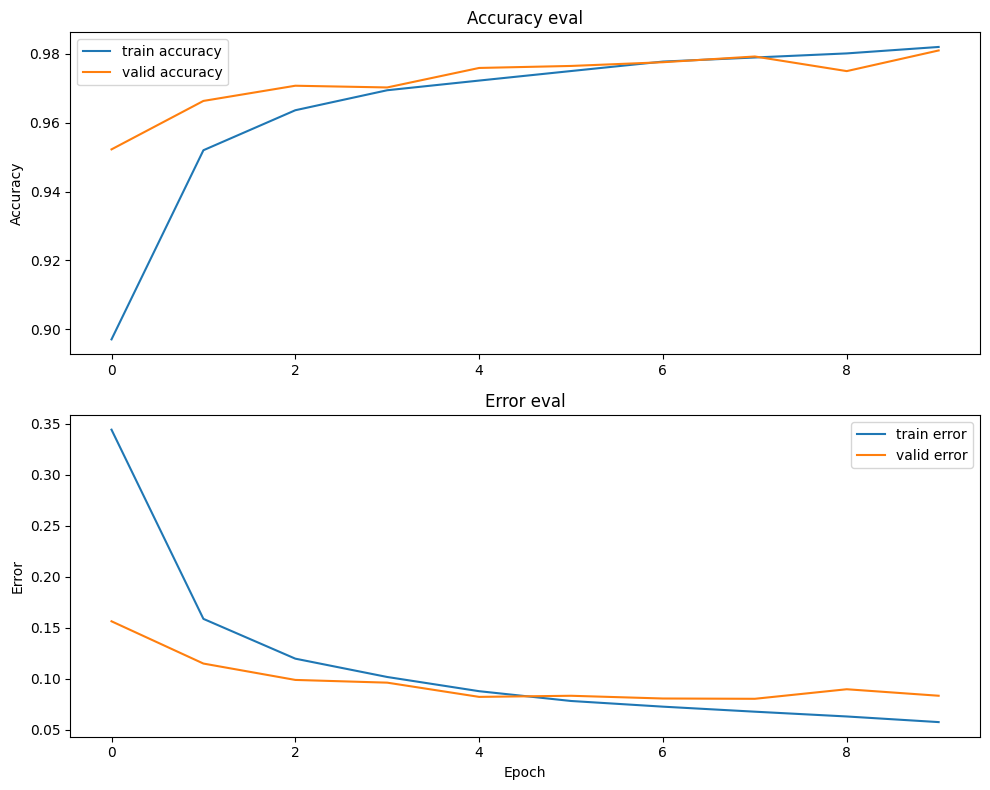

In [10]:
# plot accuracy and error over the epochs 
plot_history(model_training_history) 

### Evaluation 

In [11]:
test_loss, test_acc = evaluate(model, test_dataloader, loss_fn, device)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

Test loss: 0.0776 | Test accuracy: 0.9805


## Inference

In [12]:
def predict(model, X, y):
    class_mapping = [str(i) for i in range(10)]
    X = X.unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(X)   # add batch dim
        predicted = class_mapping[logits.argmax(1).item()]
        expected  = class_mapping[y]
    print(f"Predicted: '{predicted}' | Expected: '{expected}'")

In [13]:
test_dataset = test_dataloader.dataset 
X, y = test_dataset[100]
predict(model, X, y)

Predicted: '6' | Expected: '6'
